In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import os

import matplotlib.pyplot as plt

import sys
sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
import pylake

# Load data

In [125]:
lake= 'lucerne'
model = f'{lake}_2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('./../config.json', model)

In [126]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "seiche_analysis")
os.makedirs(output_folder, exist_ok=True)

In [127]:
grid_resolution = 100
ds['YC'] = np.arange(1, len(ds['YC'])+1) * grid_resolution - grid_resolution/2
ds['XC'] = np.arange(1, len(ds['XC'])+1) * grid_resolution - grid_resolution/2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

In [128]:
omega = 7.2921e-5  # Earth's angular velocity (rad/s)
lat_rad = np.deg2rad(46.45)# Latitude of Lake Geneva (degrees)
f = 2 * omega * np.sin(lat_rad) # Coriolis parameter
f0 = abs(f/(2*np.pi)) # conversion from rad/s to 1/s

In [129]:
g = 9.81

In [130]:
fetch_per_angle = xr.open_dataset(os.path.join(output_folder, "fetch_per_angle.nc"))

In [131]:
if lake=='zug':
    Lx = 13000
    Ly = 3000
if lake=='neuchatel':
    Lx = 38000
    Ly = 6000
if lake=='lucerne':
    Lx = 30000
    Ly = 3000


In [132]:
ds = ds.sel(time=slice('2025-07-01', '2025-08-01'))

# Compute Rho

In [ ]:
rho = pylake.dens0(s=0.2, t=ds['THETA']).where(ds['THETA']>0)

# Define the 2 layers

In [ ]:
mean_rho_profile = rho.mean(dim=['XC','YC']).compute()

In [ ]:
mean_rho_profile.to_netcdf(os.path.join(output_folder, r'mean_rho_profile.nc'))

In [133]:
mean_rho_profile = xr.open_dataarray(os.path.join(output_folder, r'mean_rho_profile.nc'))

In [134]:
thermocline_depth=[]
thermocline_idx = []
for i in range(len(mean_rho_profile.time)):
    depth_temp, idx_temp = pylake.thermocline(mean_rho_profile.isel(time=i).values, -1*mean_rho_profile['Z'].values, mixed_cutoff=0.7)
    thermocline_depth.append(depth_temp)
    thermocline_idx.append(idx_temp)

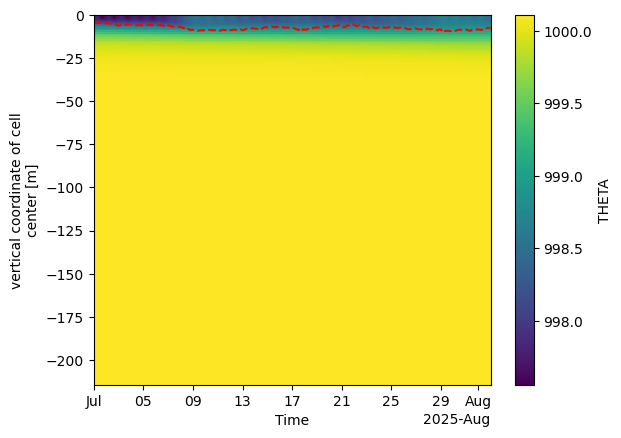

In [135]:
mean_rho_profile.plot(y='Z')
plt.plot(mean_rho_profile.time, -1*np.array(thermocline_depth), color='r', linestyle='--')

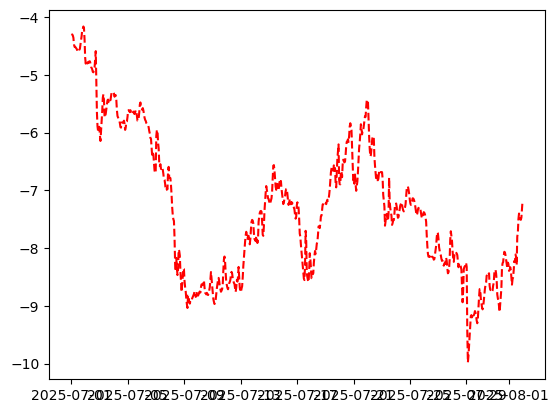

In [136]:
plt.plot(mean_rho_profile.time, -1*np.array(thermocline_depth), color='r', linestyle='--')

In [137]:
rho1 = []
rho2 = []
for i in range(len(thermocline_depth)):
    rho1.append(mean_rho_profile.isel(Z=range(0, thermocline_idx[i])).mean())
    rho2.append(mean_rho_profile.isel(Z=range(thermocline_idx[i], len(ds.Z))).mean())
rho1 = np.array(rho1)
rho2 = np.array(rho2)

In [138]:
H_mean = 64 #geneva: 150
h1 = np.array(thermocline_depth)
h2 = H_mean - h1

In [139]:
g_prime = g*(rho2-rho1)/rho2

In [ ]:
H_bar = h1*h2/(h1+h2)
c_phase = np.sqrt(g_prime*H_bar)
plt.plot(mean_rho_profile.time, c_phase)

In [ ]:
T_iw = 2*Lx/c_phase
T_iw_in_hour = T_iw / 3600
plt.plot(mean_rho_profile.time, T_iw_in_hour)

In [ ]:
Rd = c_phase / f0
plt.plot(mean_rho_profile.time, Rd)

In [ ]:
Bu = (Rd / Lx)**2
plt.plot(mean_rho_profile.time, Bu)

In [ ]:
i_time = 720
print(f'Date: {mean_rho_profile.time[i_time].values}')
print(f'Thermocline depth  = {thermocline_depth[i_time]:.2f} m')
print(f'Rossby radius of deformation = {Rd[i_time]:.2f} m2/s')
print(f'Wave phase velocity = {c_phase[i_time]:.2f} m/s')
print(f'Burger Number = {Bu[i_time]:.2f} m2/s2')

# Wind analysis

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [140]:
base_folder = rf'/home/leroquan@eawag.wroot.emp-eaw.ch/work_space/{lake}_100m_2025'
bin_folder = os.path.join(base_folder, 'binary_data')
ds_wind = xr.open_dataset(os.path.join(bin_folder, 'wind.nc'))

#wind_file = r"/storage/alplakes_test/geneva_100m_2025/sta_meteo/2025.json"
#with open(wind_file, 'r') as f:
#    wind_data = json.load(f)

In [141]:
ds_wind = ds_wind.sel(time=slice('2025-07-01', '2025-08-01'))

In [142]:
wind_speed = ds_wind.speed

wind_speed = np.array(wind_data['variables']['wind_speed']['data'])
wind_date = pd.to_datetime(wind_data['time'])

plt.plot(wind_date, wind_speed)

# Following the MITgcm calculation
drag_coeff1 = 0.00135
drag_coeff2 = 0.000071
drag_coeff3 = 0.0000382

def compute_cd(wind_speed):
    cd = drag_coeff1 / wind_speed + drag_coeff2 + drag_coeff3 * wind_speed
    return cd

test_speed_arr = np.array([0.5, 1, 2 ,3, 4, 5, 6, 7, 10, 12])
plt.plot(test_speed_arr, compute_cd(test_speed_arr))

cd = compute_cd(wind_speed[:-48])

In [143]:
cd = xr.open_dataarray(os.path.join(folder_path, 'wind_analysis', 'Cd.nc'))
cd = cd.sel(time=slice('2025-07-01', '2025-08-01'))
cd['time'] = ds_wind['time']
cd['x'] = ds_wind['x']
cd['y'] = ds_wind['y']

In [144]:
u_star = np.sqrt(cd) * wind_speed

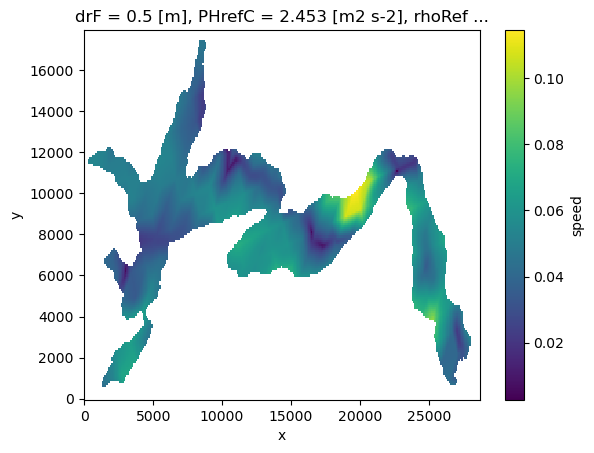

In [145]:
u_star.isel(time=24).plot()

# Richardson number

In [146]:
xr_g_prime = xr.DataArray(
    g_prime,
    dims=["time"],
    coords={"time": u_star.time},
    name="g_prime"
)

In [147]:
Ri= xr_g_prime*h1/(0.4*u_star**2)

In [ ]:
plt.plot(Ri.mean(dim=['x','y']))

# Wedderburn Number

In [148]:
xr_fetch = fetch_per_angle.fetch.sel(
    angle=ds_wind.direction,
    method="nearest"
)

In [149]:
xr_h1 = xr.DataArray(
    h1,
    dims=["time"],
    coords={"time": u_star.time},
    name="h1"
)

In [150]:
W = Ri * xr_h1 / xr_fetch.max(dim=['x','y'])

In [ ]:
xr_fetch.max(dim=['x','y']).plot()

In [ ]:
W.isel(x=20, y=100).plot()

Text(0, 0.5, 'Wedderburn Number W [-]')

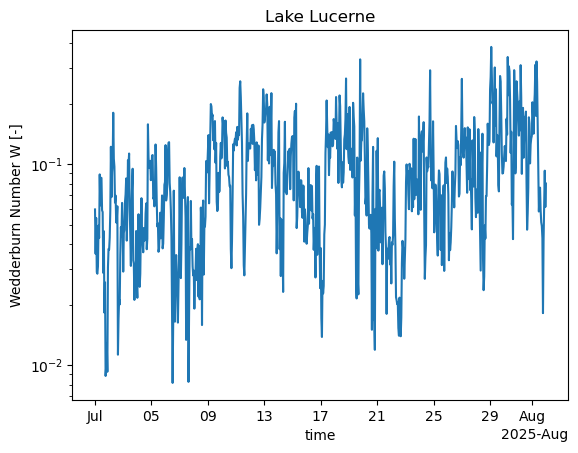

In [151]:
W.mean(dim=['x','y']).plot()
plt.gca().set_yscale('log')
plt.title(f'Lake {lake.capitalize()}')
plt.ylabel('Wedderburn Number W [-]')

In [ ]:
plt.plot(ds_wind.time, W)
plt.gca().set_yscale('log')
plt.title(f'Lake {lake.capitalize()}')
plt.ylabel('Wedderburn Number W [-]')

In [ ]:
plt.plot(g_prime*(h1**2)/(Lx*(u_star.mean(dim=['x','y'])**2)))
plt.gca().set_yscale('log')

In [ ]:
he_over_H = np.array(thermocline_depth)/(h1+h2)

In [ ]:
plt.scatter(he_over_H, 1/W)
plt.xlabel('h_e/H')
plt.ylabel('1/W')
plt.gca().set_yscale('log')
plt.plot(he_over_H, 1/(np.array(thermocline_depth)/Lx))
plt.plot(he_over_H, 1/(0.5*np.sqrt((h1+h2)/h2)))
plt.plot(he_over_H, 1/(Lx*(h1+h2)/(4*h1*h2)))

In [ ]:
Lx = 30000

W = Ri * h1 / Lx
he_over_L = np.array(thermocline_depth)/Lx
plt.scatter(he_over_L, W)
plt.xlabel('h_e/L')
plt.ylabel('W')
plt.gca().set_yscale('log')
#plt.ylim(1e-4, 1e1)
plt.plot(he_over_L, h2/Lx)
plt.plot(he_over_L, 1/(0.5*np.sqrt((h1+h2)/h2)))
plt.plot(he_over_L, 1/(Lx*(h1+h2)/(4*h1*h2)))

# Wave period

In [ ]:
# Wave number [rad/m]
k = np.pi / Lx #np.sqrt(Lx**2+Ly**2)

In [ ]:
# Wave frequency [rad/s]
w = np.sqrt(k**2 * c_phase**2 + f**2)

In [ ]:
# Period [s]
T = 2 * np.pi / w

In [ ]:
plt.plot(T/3600)

# Compute energy per amplitude

In [ ]:
def compute_theoritical_energy(A, w, H_bar,k,S_lake,rho2):
    E_mean = 1/2 * w**2 * A**2 /(H_bar * k**2) # J x m / kg --> vertically integrated mean energy of the inertial wave

    return E_mean * S_lake * rho2 # J

In [ ]:
S_lake = np.count_nonzero(ds['THETA'].isel(time=0,Z=0)>0)*(100**2)

In [ ]:
plt.plot(compute_theoritical_energy(1, w, H_bar,k,S_lake,rho2)/1e6)

# Compute wave amplitude

In [ ]:
xx1 = 49850 # Lexplore
yy1 = 18100
rho_lexplore = rho.sel(XC=xx1, YC=yy1, method='nearest').compute()

In [ ]:
thermocline_depth_lexplore = []
thermocline_idx_lexplore = []
for i in range(len(mean_rho_profile.time)):
    depth_temp, idx_temp = pylake.thermocline(rho_lexplore.isel(time=i).values, -1 * rho_lexplore['Z'].values,
                                              mixed_cutoff=0.7)
    thermocline_depth_lexplore.append(depth_temp)
    thermocline_idx_lexplore.append(idx_temp)

In [ ]:
plt.plot(thermocline_depth_lexplore)

In [ ]:
from utils_signal_processing import *

In [ ]:
M = 4
dt = 3600

In [ ]:
thermocline_depth_arr = np.asarray(thermocline_depth_lexplore)
thermocline_depth_clean = thermocline_depth_arr[~np.isnan(np.asarray(thermocline_depth_lexplore))]
time_clean = ds.time.values[~np.isnan(np.asarray(thermocline_depth_lexplore))]

N = len(thermocline_depth_clean)

In [ ]:
amp_mean, err_up, err_low = compute_mean_fft(thermocline_depth_clean, M=M)

In [ ]:
p = N // M
freq = np.fft.fftfreq(p, dt)[:p // 2]

In [ ]:
amp_mean_da = xr.DataArray(amp_mean, dims=["freq"], coords={"freq": freq})
err_up_da = xr.DataArray(err_up, dims=["freq"], coords={"freq": freq})
err_low_da = xr.DataArray(err_low, dims=["freq"], coords={"freq": freq})
thermo_depth_fft = xr.Dataset(
        {
            "amp_mean": amp_mean_da,
            "err_up": err_up_da,
            "err_low": err_low_da,
        },
        coords={"freq": freq}
    )

In [ ]:
fig, ax = plt.subplots(1, figsize=(8, 5))
ax.fill_between(thermo_depth_fft['freq'],
                thermo_depth_fft.err_low,
                thermo_depth_fft.err_up,
                color='gray', alpha=0.5, label='Uncertainty')
ax.plot(thermo_depth_fft['freq'], thermo_depth_fft.amp_mean, label='Mean')
# Set both axes to log scale
ax.set_xscale('log')
ax.set_yscale('log')

In [ ]:
cutoff1_hr = 20
cutoff2_hr = 16

cutoff1 = 1/(cutoff1_hr * 3600)
cutoff2 = 1/(cutoff2_hr * 3600)

In [ ]:
fig,ax = plot_freq_spectrum(thermo_depth_fft, 'thermocline depth', depth=0, m_segm=1, y_lim_min=1e-6, x_lim_min=1e-7, fontsize=10)
ax.axvline(x = cutoff1, linestyle="--", color="k",label="cutoff1")
ax.axvline(x = cutoff2, linestyle="--", color="k",label="cutoff2")
ax.legend()

In [ ]:
thermo_depth_filtered = filter_signal_timeseries(thermocline_depth_clean, btype='bandpass', dt=3600, period_cutoff_low=17*3600, period_cutoff_high=16*3600, order=5)

In [ ]:
plt.plot(thermo_depth_filtered)

In [ ]:
df_thermo_depth_filtered = pd.Series(thermo_depth_filtered)
df_amplitude_max = df_thermo_depth_filtered.rolling(window=17).max()

In [ ]:
df_amplitude_max.plot()

In [ ]:
len(df_amplitude_max)

In [ ]:
E_tot = compute_theoritical_energy(df_amplitude_max, w[~np.isnan(thermocline_depth_arr)], H_bar[~np.isnan(thermocline_depth_arr)],k,S_lake,rho2[~np.isnan(thermocline_depth_arr)])

In [ ]:
base_path = r"/storage/alplakes_test/geneva_100m_2025"
eddy_folder_path = os.path.join(base_path, "outputs_swirl", "ke_eddy")
eddy_ke = pd.read_csv(os.path.join(eddy_folder_path, "ke_eddies.csv"), index_col=0)
lake_ke = pd.read_csv(os.path.join(eddy_folder_path, "ke_lake.csv"), index_col=0)
eddy_ke['date'] = pd.to_datetime(eddy_ke['date'])
lake_ke['date'] = pd.to_datetime(lake_ke['date'])
eddy_ke = eddy_ke.set_index('date')
lake_ke = lake_ke.set_index('date')

In [ ]:
fig, ax = plt.subplots(1, figsize=(15, 5))
lake_ke.plot(ax=ax)
ax.plot(time_clean, E_tot/1e6)
plt.xlim(pd.to_datetime("2025-05-01"), pd.to_datetime("2025-09-01"))